In [1]:
#Bu notebookda koordinatların yoğunluk haritası çıkartıalcak daha sonra ısı haritası oluşacak.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

In [2]:
df = pd.read_csv('/kaggle/input/datasets/zlemdemir/koordinatlar/koordinatlar_for_2_person.csv')

# Sadece person sınıfını tut
df = df[df['class'] == 'person']

print(f"Toplam koordinat: {len(df)}")
print(f"Benzersiz ID'ler: {sorted(df['id'].unique())}")
print(f"X aralığı: {df['x'].min():.0f} - {df['x'].max():.0f}")
print(f"Y aralığı: {df['y'].min():.0f} - {df['y'].max():.0f}")

Toplam koordinat: 268
Benzersiz ID'ler: [np.int64(1), np.int64(2)]
X aralığı: 154 - 575
Y aralığı: 108 - 306


In [3]:
video_width = 640
video_height = 360

heatmap = np.zeros((video_height, video_width))

for _, row in df.iterrows():
    x = int(row['x'])
    y = int(row['y'])
    if 0 <= x < video_width and 0 <= y < video_height:
        heatmap[y, x] += 1

heatmap_smooth = gaussian_filter(heatmap, sigma=15)

print(f"Isı haritası boyutu: {heatmap_smooth.shape}")
print(f"Max yoğunluk: {heatmap_smooth.max():.2f}")

Isı haritası boyutu: (360, 640)
Max yoğunluk: 0.03


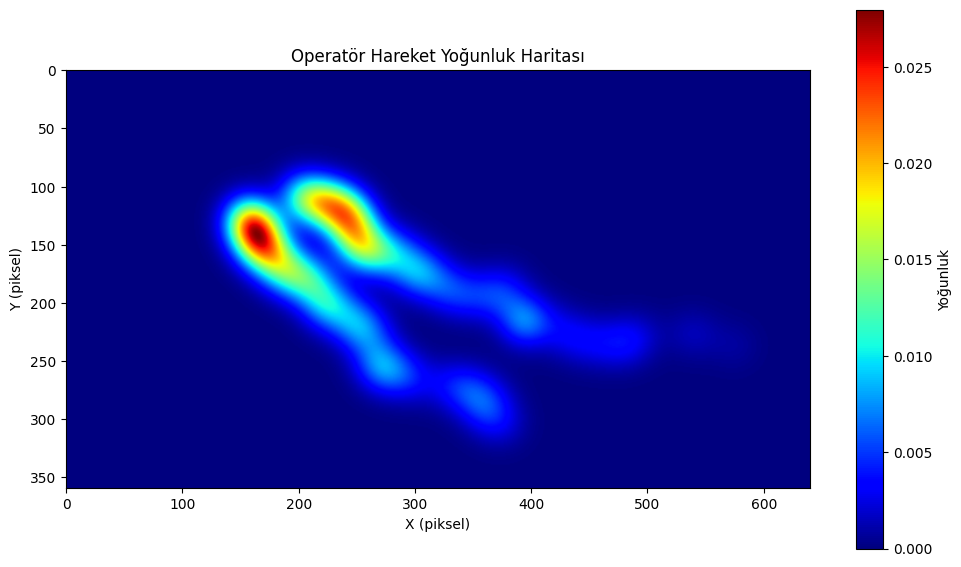

In [4]:
plt.figure(figsize=(12, 7))
plt.imshow(heatmap_smooth, cmap='jet', interpolation='bilinear')
plt.colorbar(label='Yoğunluk')
plt.title('Operatör Hareket Yoğunluk Haritası')
plt.xlabel('X (piksel)')
plt.ylabel('Y (piksel)')
plt.savefig('/kaggle/working/isi_haritasi.png', dpi=150, bbox_inches='tight')
plt.show()